In [18]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

credit_df = pd.read_csv("Credit_card.csv")
credit_df.head()


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [19]:
gender_map = {'M':0, 'F':1}
credit_df['GENDER'] = credit_df['GENDER'].map(gender_map)

car_map = {'N':0, 'Y':1}
credit_df['Car_Owner'] = credit_df['Car_Owner'].map(car_map)

property_map = {'N':0, 'Y':1}
credit_df['Propert_Owner'] = credit_df['Propert_Owner'].map(property_map)

income_map = {'Commercial associate':0, 'Pensioner':1, 'State servant':2, 'Working':3}
credit_df['Type_Income'] = credit_df['Type_Income'].map(income_map)

education_map = {'Academic degree':0, 'Higher educaton':1, 'Incomplete higher':2, 
                 'Lower secondary':3, 'Secondary / secondary special':4}
credit_df['EDUCATION'] = credit_df['EDUCATION'].map(education_map)

married_map = {'Civil marriage':0, 'Married':1, 'Separated':2, 'Single / not married':3, 'Widow':4}
credit_df['Marital_status'] = credit_df['Marital_status'].map(married_map)

housing_map = {'Co-op apartment':0, 'House / apartment':1, 'Municipal apartment':2, 
               'Office apartment':3, 'Rented apartment':4, 'With parents':5}
credit_df['Housing_type'] = credit_df['Housing_type'].map(housing_map)

occupation_map = {'Accountants':0, 'Cleaning staff':1, 'Cooking staff':2, 
                  'Core staff':3, 'Drivers':4, 'HR staff':5, 'High skill tech staff':6, 
                  'IT staff':7, 'Laborers':8, 'Low-skill laborers':9, 'Managers':10, 
                  'Medicine staff':11, 'Private service staff':12, 'Realty agents':13,
                  'Sales staff':14, 'Secretaries':15, 'Security staff':16, 
                  'Waiters/barmen staff':17}
credit_df['Type_Occupation'] = credit_df['Type_Occupation'].map(occupation_map)

credit_df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,0.0,1,1,0,180000.0,1,NaN,1,1,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,1.0,1,0,0,315000.0,0,NaN,1,1,NaN,-586,1,1,1,0,NaN,2
3,5009749,1.0,1,0,0,NaN,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,1.0,0,1,0,NaN,0,NaN,1,1,-11957.0,-2182,1,0,0,0,10.0,2
1544,5023655,1.0,0,0,0,225000.0,0,2.0,3,1,-10229.0,-1209,1,0,0,0,0.0,1
1545,5115992,0.0,1,1,2,180000.0,3,NaN,1,1,-13174.0,-2477,1,0,0,0,10.0,4
1546,5118219,0.0,1,0,0,270000.0,3,4.0,0,1,-15292.0,-645,1,1,1,0,4.0,2


In [20]:
credit_df.dropna()
credit_df.drop_duplicates()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,0.0,1,1,0,180000.0,1,NaN,1,1,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,1.0,1,0,0,315000.0,0,NaN,1,1,NaN,-586,1,1,1,0,NaN,2
3,5009749,1.0,1,0,0,NaN,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,1.0,1,0,0,315000.0,0,NaN,1,1,-13557.0,-586,1,1,1,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,1.0,0,1,0,NaN,0,NaN,1,1,-11957.0,-2182,1,0,0,0,10.0,2
1544,5023655,1.0,0,0,0,225000.0,0,2.0,3,1,-10229.0,-1209,1,0,0,0,0.0,1
1545,5115992,0.0,1,1,2,180000.0,3,NaN,1,1,-13174.0,-2477,1,0,0,0,10.0,4
1546,5118219,0.0,1,0,0,270000.0,3,4.0,0,1,-15292.0,-645,1,1,1,0,4.0,2


In [21]:
credit_df = credit_df[['Type_Income','Propert_Owner']]

X = np.array(credit_df['Type_Income']).reshape(-1,1)

y = np.array(credit_df['Propert_Owner']).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [22]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [23]:
regression = LogisticRegression(random_state=42).fit(X_train, y_train)
y_pred = regression.predict(X_test)

y_pred

c:\Users\kaste\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

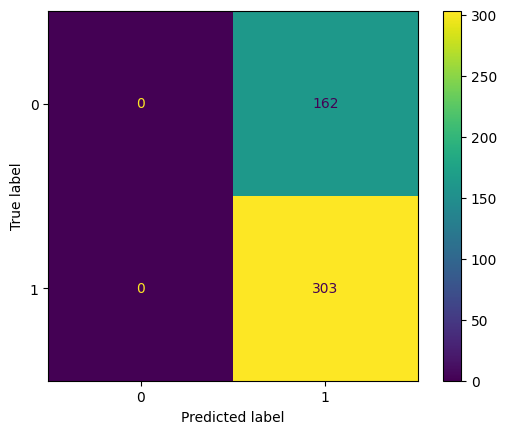

In [24]:
ConfusionMatrixDisplay.from_estimator(regression, X_test, y_test)

In [31]:
303/(303+162)

0.6516129032258065

In [27]:
credit_df.columns

Index(['Type_Income', 'Propert_Owner'], dtype='str')

In [28]:
pca = PCA(n_components = 2)
pca.fit(credit_df)
data_pca = pca.transform(credit_df)
data_pca = pd.DataFrame(data_pca,columns=['Type_Income','Propert_Owner'])
data_pca.head()

,Type_Income,Propert_Owner
0,-0.878581,0.325659
1,-1.853240,-0.699056
2,-1.853240,-0.699056
3,-1.853240,-0.699056
4,-1.853240,-0.699056


<Axes: >

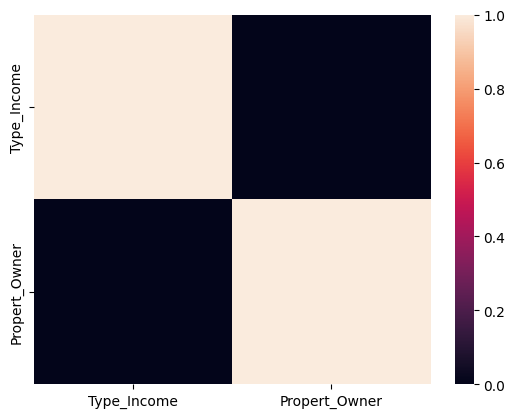

In [29]:
sns.heatmap(data_pca.corr())

The precision of the original model was about 65%. This is a pretty bad score, as we are shooting for 100%. However, looking at it through the lens of PCA, there is absolutely no correlation between the two columns, so 65% seems like quite a high rating for this model. 